# Requirements

# Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud

# Load the Dataset

In [5]:
df = pd.read_csv("Virat_Kohli_Centuries.csv")

# EDA (Exploratory Data Analysis)

In [7]:
df.shape
# Number of rows and columns

(80, 14)

In [8]:
df.columns
# All column names

Index(['S. No.', 'Date', 'Score', 'Strike Rate', 'Type of Match', 'Position',
       'Innings', 'Dismissed', 'Man of the Match', 'Captain', 'Against',
       'Venue', 'H/A/N', 'Result'],
      dtype='object')

In [9]:
df.info()
# This gives a summary of your data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S. No.            80 non-null     int64  
 1   Date              80 non-null     object 
 2   Score             80 non-null     int64  
 3   Strike Rate       80 non-null     float64
 4   Type of Match     80 non-null     object 
 5   Position          80 non-null     int64  
 6   Innings           80 non-null     int64  
 7   Dismissed         80 non-null     object 
 8   Man of the Match  80 non-null     object 
 9   Captain           80 non-null     object 
 10  Against           80 non-null     object 
 11  Venue             80 non-null     object 
 12  H/A/N             80 non-null     object 
 13  Result            80 non-null     object 
dtypes: float64(1), int64(4), object(9)
memory usage: 8.9+ KB


In [10]:
df.dtypes
# Data types of the values in the columns

S. No.                int64
Date                 object
Score                 int64
Strike Rate         float64
Type of Match        object
Position              int64
Innings               int64
Dismissed            object
Man of the Match     object
Captain              object
Against              object
Venue                object
H/A/N                object
Result               object
dtype: object

In [11]:
df.head()
# The first few values

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
0,1,24-12-2009,107,93.85,ODI,4,2,Yes,No,No,Sri Lanka,"Eden Gardens, Kolkata",Home,Won
1,2,11-01-2010,102,107.37,ODI,3,2,No,Yes,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won
2,3,20-10-2010,118,97.52,ODI,3,2,Yes,Yes,No,Australia,"APCA-VDCA Stadium, Visakhapatnam",Home,Won
3,4,28-11-2010,105,100.96,ODI,3,1,Yes,Yes,No,New Zealand,"Nehru Stadium, Guwahati",Home,Won
4,5,19-02-2011,100,120.48,ODI,4,1,No,No,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won


In [12]:
df.tail()
# The last few values

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
75,76,10-10-2019,254,75.59,Test,4,1,No,Yes,Yes,South Africa,"Maharashtra Cricket Association Stadium, Pune",Home,Won
76,77,22-11-2019,136,70.10,Test,4,2,Yes,No,Yes,Bangladesh,"Eden Gardens, Kolkata",Home,Won
77,78,09-03-2023,186,51.09,Test,4,2,Yes,Yes,No,Australia,"Narendra Modi Stadium, Ahmedabad",Home,Drawn
78,79,20-07-2023,121,58.73,Test,4,1,Yes,No,No,West Indies,"Queen's Park Oval, Port of Spain",Away,Drawn
79,80,08-09-2022,122,200.00,T20,2,1,No,Yes,No,Afghanistan,"Dubai International Cricket Stadium, Dubai",Neutral,Won


In [13]:
df["Score"].nlargest(10)
# Top 10 largest values

75    254
69    243
64    235
68    213
62    211
65    204
61    200
77    186
10    183
58    169
Name: Score, dtype: int64

In [14]:
df["Strike Rate"].nlargest(10)

79    200.00
15    192.30
54    192.13
16    174.24
8     154.65
45    150.90
28    136.45
34    134.37
35    130.84
44    129.88
Name: Strike Rate, dtype: float64

In [15]:
df["Type of Match"].unique()
# The unique values

array(['ODI', 'Test', 'T20'], dtype=object)

In [16]:
df["Type of Match"].nunique()
# Number of unique values

3

In [17]:
df["Against"].value_counts()
# Number of times data in rows has occurred in a column

Against
Australia       16
Sri Lanka       15
West Indies     12
New Zealand      9
England          8
South Africa     8
Bangladesh       7
Pakistan         3
Zimbabwe         1
Afghanistan      1
Name: count, dtype: int64

In [18]:
df["Type of Match"].value_counts()

Type of Match
ODI     50
Test    29
T20      1
Name: count, dtype: int64

# Condition Based Analysis

In [20]:
df[df["Against"] == "Pakistan"]

# Here we are seeing all the centuries by Virat Kohli against Pakistan

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
10,11,18-03-2012,183,123.64,ODI,3,2,Yes,Yes,No,Pakistan,"Sher-e-Bangla Stadium, Dhaka",Neutral,Won
21,22,15-02-2015,107,84.90,ODI,3,1,Yes,Yes,No,Pakistan,"Adelaide Oval, Adelaide",Neutral,Won
46,47,10-09-2023,122,129.78,ODI,3,1,No,Yes,No,Pakistan,"R. Premadasa Stadium, Colombo",Neutral,Won


In [21]:
df[df["Against"] == "Australia"].shape

# This gives us the number of rows and columns where Virat Kohli has scored centuries against Australia

(16, 14)

In [22]:
df[df["Score"] > 150]

# All values where the score is above 150

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
10,11,18-03-2012,183,123.64,ODI,3,2,Yes,Yes,No,Pakistan,"Sher-e-Bangla Stadium, Dhaka",Neutral,Won
25,26,23-10-2016,154,114.92,ODI,3,2,No,Yes,No,New Zealand,"IS Bindra Stadium, Mohali",Home,Won
33,34,07-02-2018,160,100.62,ODI,3,1,No,Yes,Yes,South Africa,"Newlands Cricket Ground, Cape Town",Away,Won
36,37,24-10-2018,157,121.71,ODI,3,1,No,Yes,Yes,West Indies,"ACA-VDCA Stadium, Visakhapatnam",Home,Tied
45,46,15-01-2023,166,150.90,ODI,3,1,No,Yes,No,Sri Lanka,"Greenfield International Stadium, Thiruvananth...",Home,Won
58,59,26-12-2014,169,62.13,Test,4,2,Yes,No,No,Australia,"Melbourne Cricket Ground, Melbourne",Away,Drawn
61,62,21-07-2016,200,70.67,Test,4,1,Yes,No,Yes,West Indies,"Sir Vivian Richards Stadium, Antigua",Away,Won
62,63,08-10-2016,211,65.87,Test,4,1,Yes,No,Yes,New Zealand,"Holkar Stadium, Indore",Home,Won
63,64,17-11-2016,167,72.78,Test,4,1,Yes,Yes,Yes,England,"ACA-VDCA Cricket Stadium, Visakhapatnam",Home,Won
64,65,08-12-2016,235,69.11,Test,4,2,Yes,Yes,Yes,England,"Wankhede Stadium, Mumbai",Home,Won


In [23]:
df[df["Score"] > 150].shape

# The number of rows and columns where the score is above 150

(16, 14)

In [24]:
df[df["Strike Rate"] < 55]

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
50,51,24-01-2012,116,54.46,Test,6,2,Yes,No,No,Australia,"Adelaide Oval, Adelaide",Away,Lost
51,52,31-08-2012,103,53.36,Test,5,2,Yes,Yes,No,New Zealand,"M. Chinnaswamy Stadium, Bangalore",Home,Won
52,53,13-12-2012,103,34.91,Test,5,2,Yes,No,No,England,"Vidarbha Cricket Association Stadium, Nagpur",Home,Drawn
53,54,22-02-2013,107,51.94,Test,5,2,Yes,No,No,Australia,"M. A. Chidambaram Stadium, Chennai",Home,Won
72,73,18-08-2018,103,52.28,Test,4,3,Yes,Yes,Yes,England,"Trent Bridge, Nottingham",Away,Won
74,75,14-12-2018,123,47.85,Test,4,2,Yes,No,Yes,Australia,"Perth Stadium, Perth",Away,Lost
77,78,09-03-2023,186,51.09,Test,4,2,Yes,Yes,No,Australia,"Narendra Modi Stadium, Ahmedabad",Home,Drawn


In [25]:
df[df["Strike Rate"] < 55].shape

(7, 14)

# loc and iloc

In [27]:
df.head()

# For reference this command is very useful

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
0,1,24-12-2009,107,93.85,ODI,4,2,Yes,No,No,Sri Lanka,"Eden Gardens, Kolkata",Home,Won
1,2,11-01-2010,102,107.37,ODI,3,2,No,Yes,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won
2,3,20-10-2010,118,97.52,ODI,3,2,Yes,Yes,No,Australia,"APCA-VDCA Stadium, Visakhapatnam",Home,Won
3,4,28-11-2010,105,100.96,ODI,3,1,Yes,Yes,No,New Zealand,"Nehru Stadium, Guwahati",Home,Won
4,5,19-02-2011,100,120.48,ODI,4,1,No,No,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won


In [28]:
df.iloc[5, 4]

# The counting of python starts from 0 and it's position is 0 
# iloc is Integer Location and locates the location of an integer and 4 is the column and 5 is the row value

'ODI'

In [29]:
df.loc[2, "Against"]

# loc is location and it can locate any value except integer/float but the difference is that you have to input the column name instead of the position 

'Australia'

# Groupby and Aggregate Functions

In [31]:
df.groupby("Position")

In [32]:
x = df.groupby("Position")

In [33]:
x

In [34]:
type(x)

pandas.core.groupby.generic.DataFrameGroupBy

In [35]:
x["Score"].sum()

Position
2     122
3    5215
4    4758
5     313
6     116
Name: Score, dtype: int64

In [36]:
x["Score"].max()

Position
2    122
3    183
4    254
5    107
6    116
Name: Score, dtype: int64

In [37]:
x["Score"].min()

Position
2    122
3    100
4    100
5    103
6    116
Name: Score, dtype: int64

In [38]:
x["Score"].mean()

Position
2    122.000000
3    121.279070
4    148.687500
5    104.333333
6    116.000000
Name: Score, dtype: float64

In [39]:
x["Score"].median()

Position
2    122.0
3    116.0
4    137.5
5    103.0
6    116.0
Name: Score, dtype: float64

# Matplotlib

In [42]:
df.head()

,S. No.,Date,Score,Strike Rate,Type of Match,Position,Innings,Dismissed,Man of the Match,Captain,Against,Venue,H/A/N,Result
0,1,24-12-2009,107,93.85,ODI,4,2,Yes,No,No,Sri Lanka,"Eden Gardens, Kolkata",Home,Won
1,2,11-01-2010,102,107.37,ODI,3,2,No,Yes,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won
2,3,20-10-2010,118,97.52,ODI,3,2,Yes,Yes,No,Australia,"APCA-VDCA Stadium, Visakhapatnam",Home,Won
3,4,28-11-2010,105,100.96,ODI,3,1,Yes,Yes,No,New Zealand,"Nehru Stadium, Guwahati",Home,Won
4,5,19-02-2011,100,120.48,ODI,4,1,No,No,No,Bangladesh,"Sher-e-Bangla Stadium, Dhaka",Away,Won


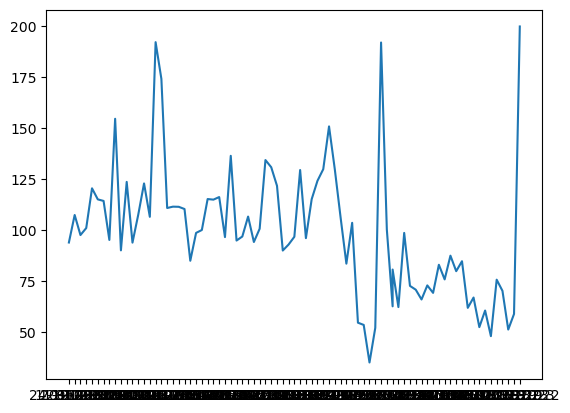

In [43]:
plt.plot(df["Date"], df["Strike Rate"])

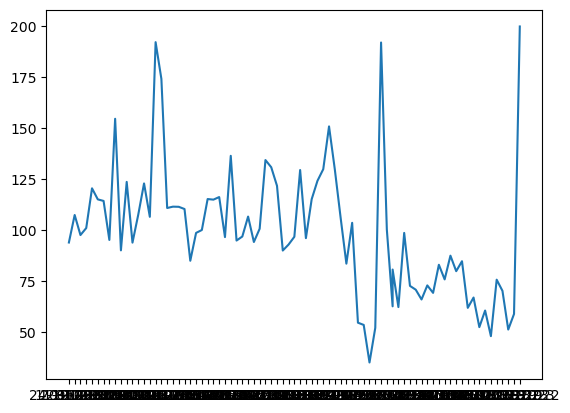

In [44]:
plt.plot(df["Date"], df["Strike Rate"])
plt.show()

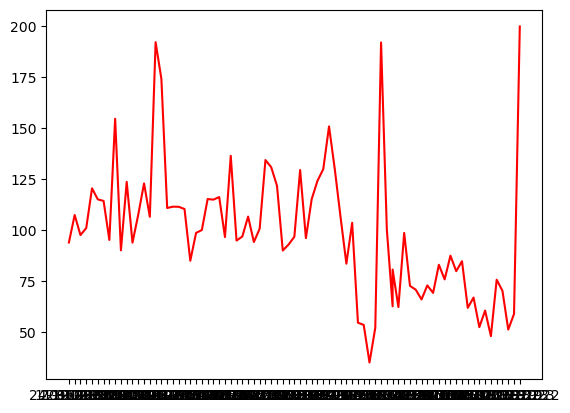

In [45]:
plt.plot(df["Date"], df["Strike Rate"], color = "red")
plt.show()

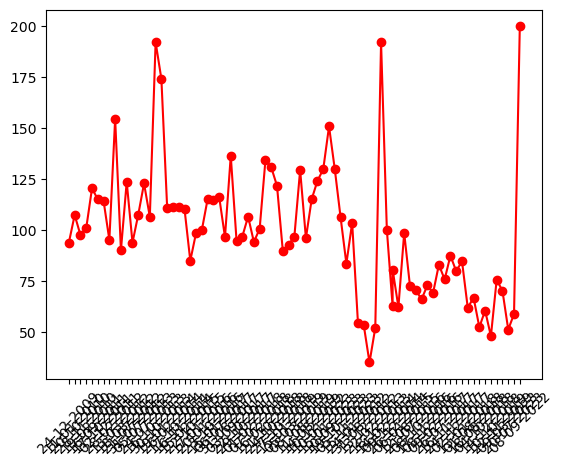

In [46]:
plt.plot(df["Date"], df["Strike Rate"], color = "red", marker = "o")
plt.xticks(rotation = 45)
plt.show()

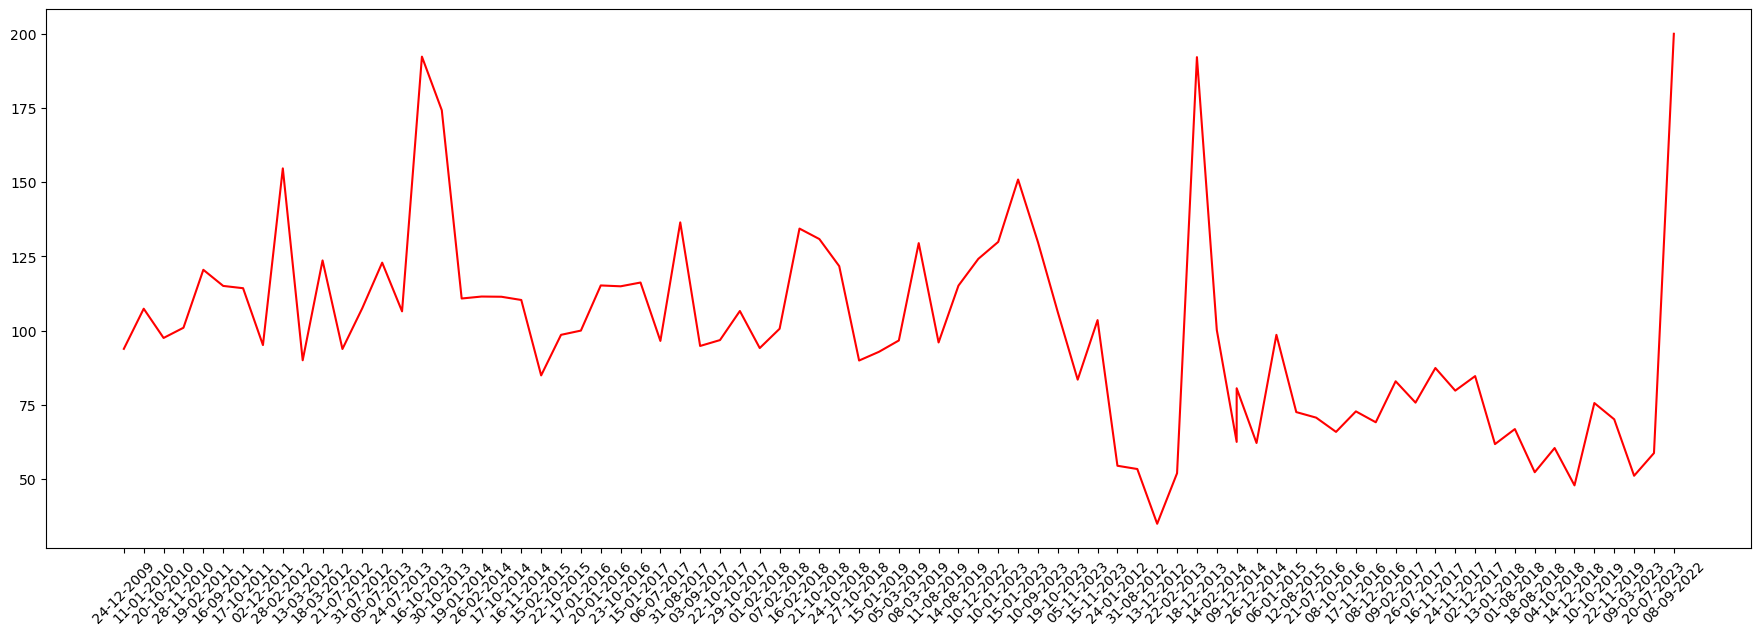

In [47]:
plt.figure(figsize = (22, 7))
plt.plot(df["Date"], df["Strike Rate"], color = "red")
plt.xticks(rotation = 45)
plt.show()

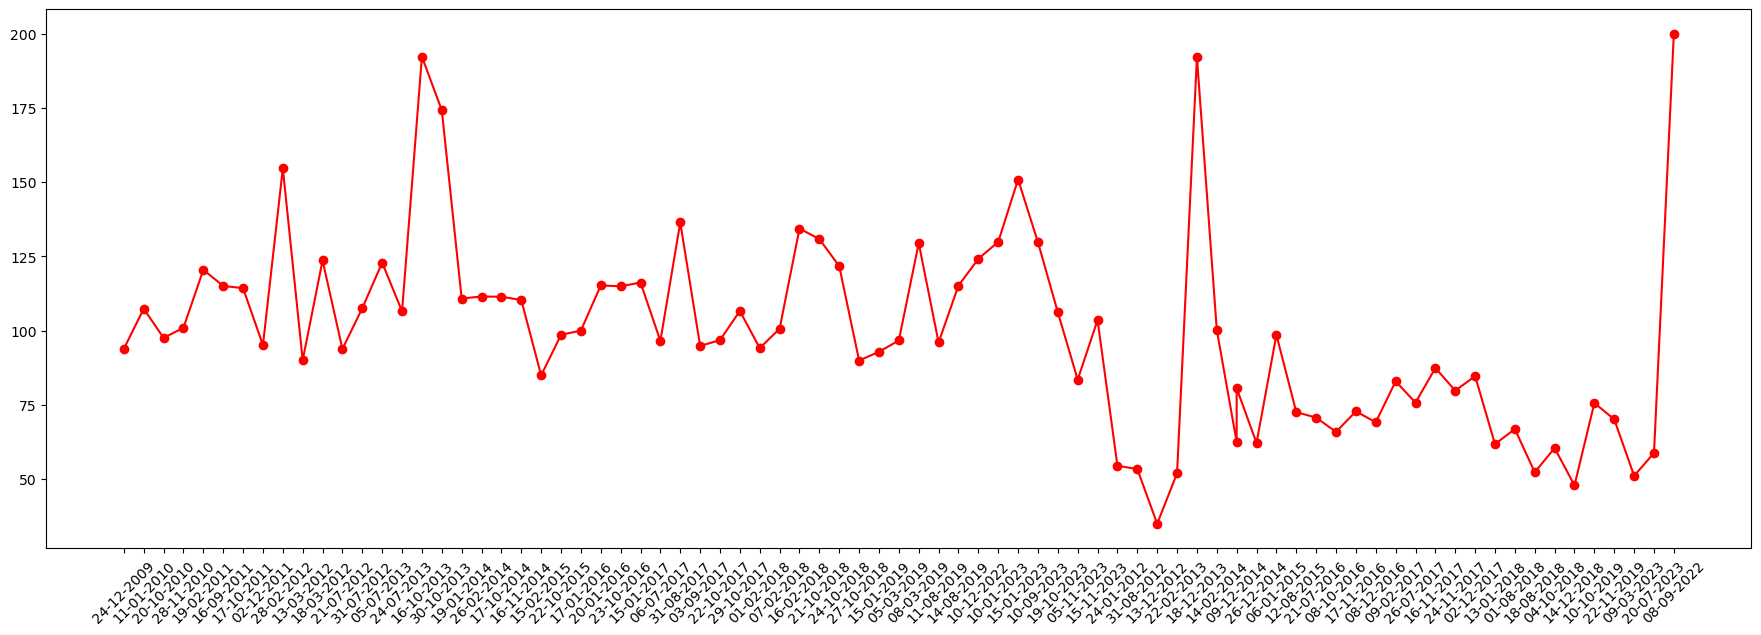

In [48]:
plt.figure(figsize = (22, 7))
plt.plot(df["Date"], df["Strike Rate"], color = "red", marker = "o")
plt.xticks(rotation = 45)
plt.show()

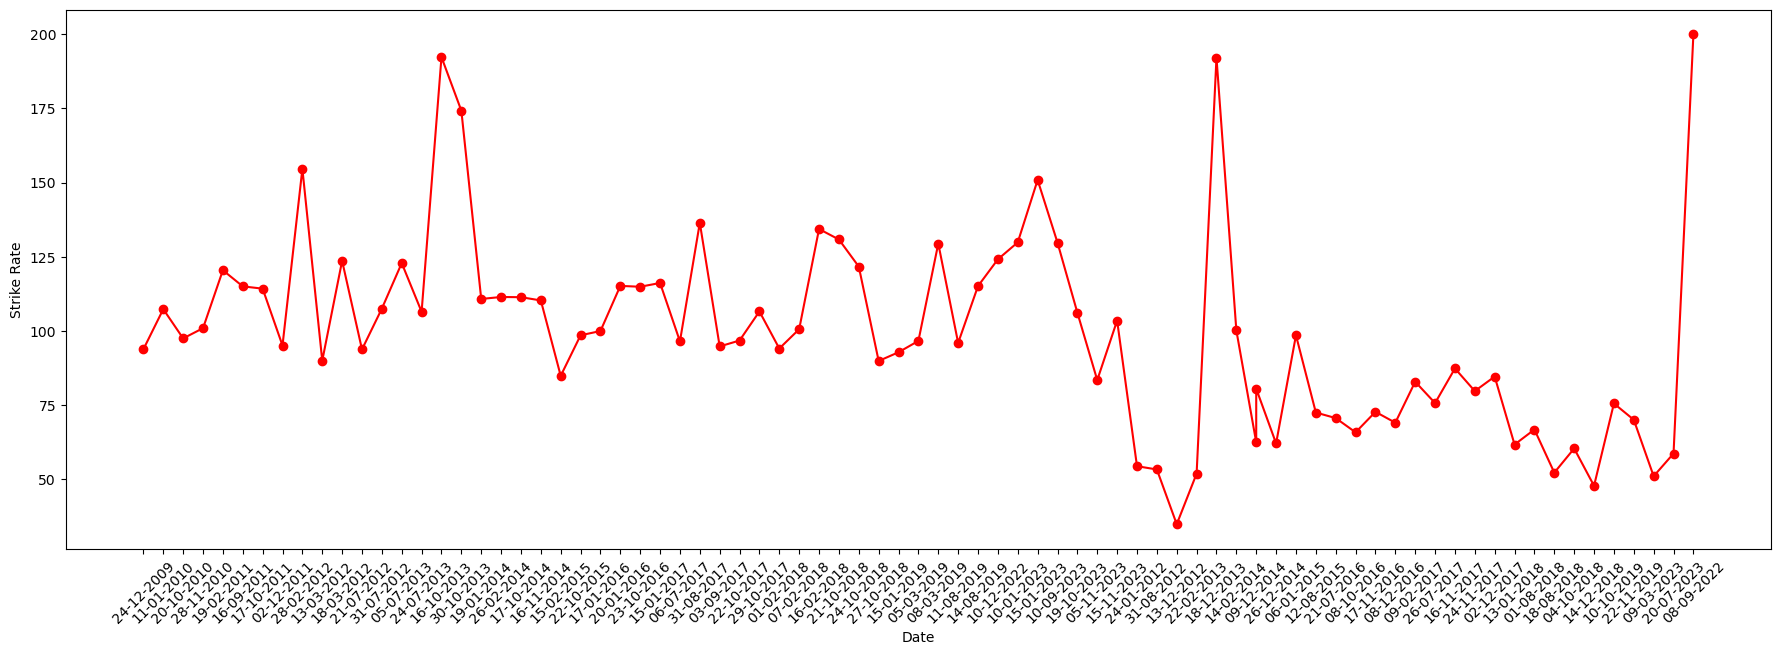

In [49]:
plt.figure(figsize = (22, 7))
plt.plot(df["Date"], df["Strike Rate"], color = "red", marker = "o")
plt.xticks(rotation = 45)
plt.xlabel("Date")
plt.ylabel("Strike Rate")
plt.show()

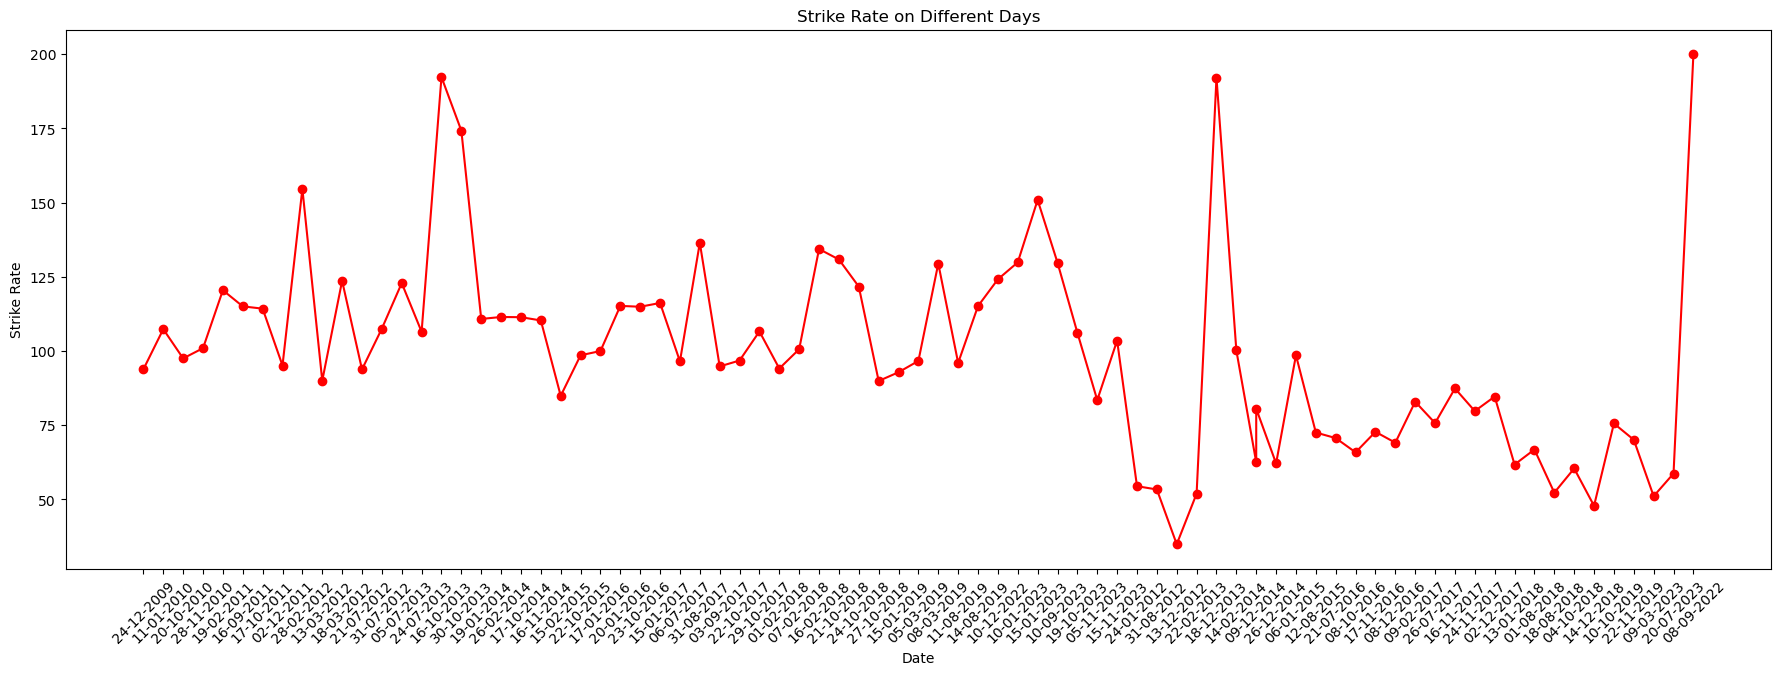

In [50]:
plt.figure(figsize = (22, 7))
plt.plot(df["Date"], df["Strike Rate"], color = "red", marker = "o")
plt.xticks(rotation = 45)
plt.xlabel("Date")
plt.ylabel("Strike Rate")
plt.title("Strike Rate on Different Days")
plt.show()

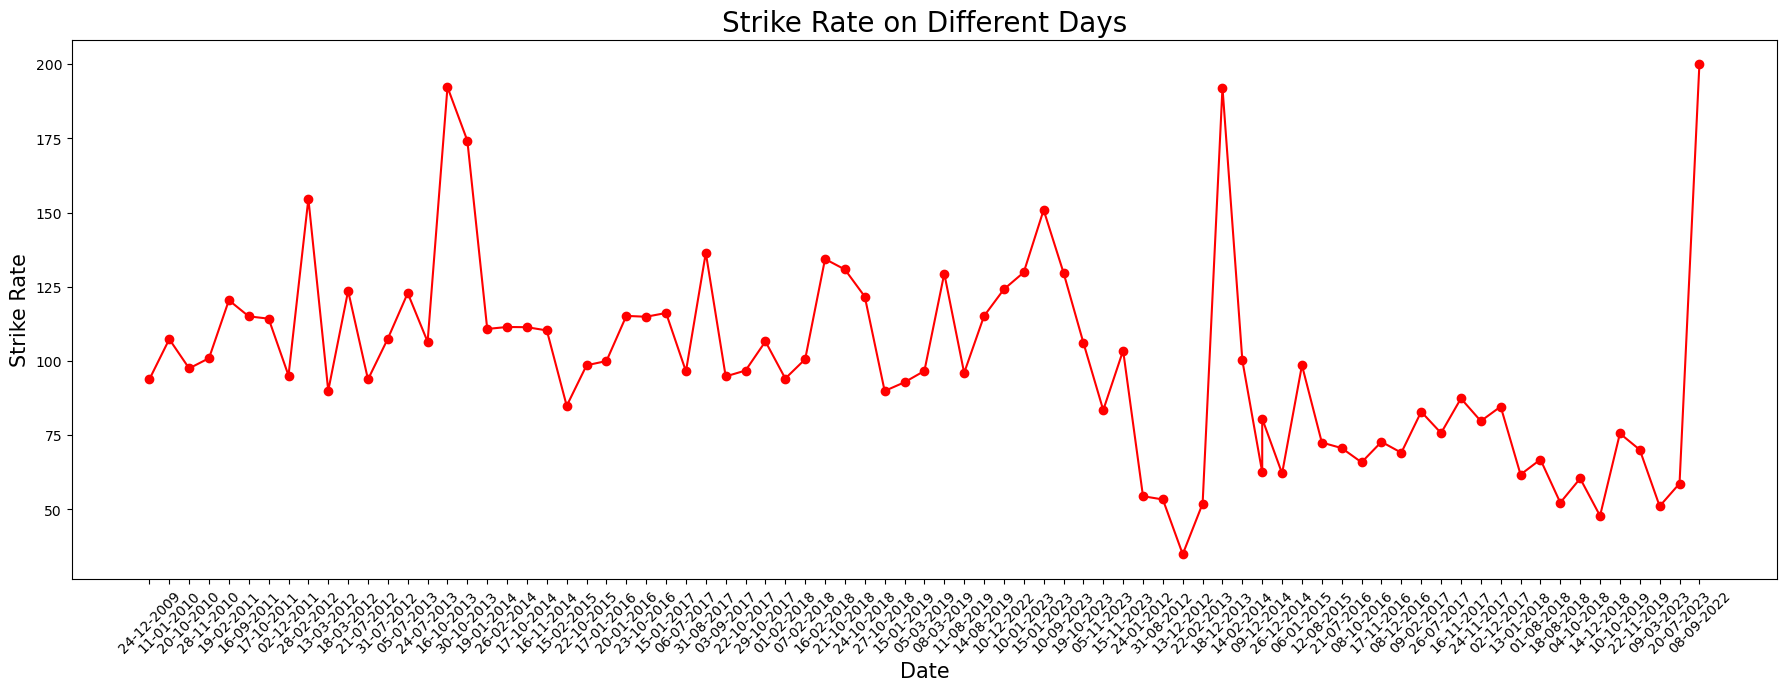

In [51]:
plt.figure(figsize = (22, 7))
plt.plot(df["Date"], df["Strike Rate"], color = "red", marker = "o")
plt.xticks(rotation = 45)
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Strike Rate", fontsize = 15)
plt.title("Strike Rate on Different Days", fontsize = 20)
plt.show()

# From the plot above I can understand that his Strike Rate was the highest on his previous century and the lowest in 2012 and his Strike Rate has slowly been going down on the days of his recent centuries.

(array([15.,  7., 16.,  9.,  8., 12.,  3.,  1.,  8.,  1.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

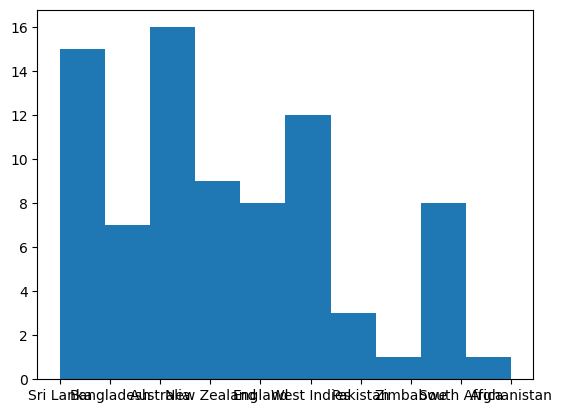

In [53]:
plt.hist(df["Against"])

(array([15.,  7.,  0., 16.,  0.,  9.,  8.,  0., 12.,  0.,  3.,  1.,  0.,
         8.,  1.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2,
        7.8, 8.4, 9. ]),
 <BarContainer object of 15 artists>)

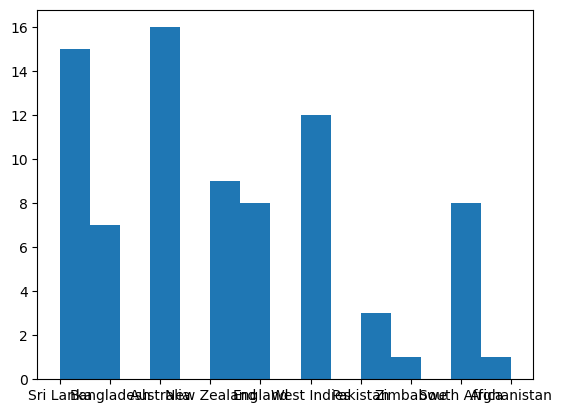

In [54]:
plt.hist(df["Against"], bins = 15)

(array([15.,  7.,  0., 16.,  0.,  9.,  8.,  0., 12.,  0.,  3.,  1.,  0.,
         8.,  1.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2,
        7.8, 8.4, 9. ]),
 <BarContainer object of 15 artists>)

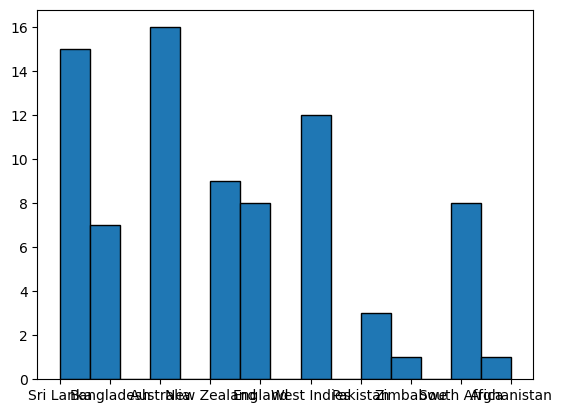

In [55]:
plt.hist(df["Against"], bins = 15, edgecolor = "black")

(array([15.,  7.,  0., 16.,  0.,  9.,  8.,  0., 12.,  0.,  3.,  1.,  0.,
         8.,  1.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2,
        7.8, 8.4, 9. ]),
 <BarContainer object of 15 artists>)

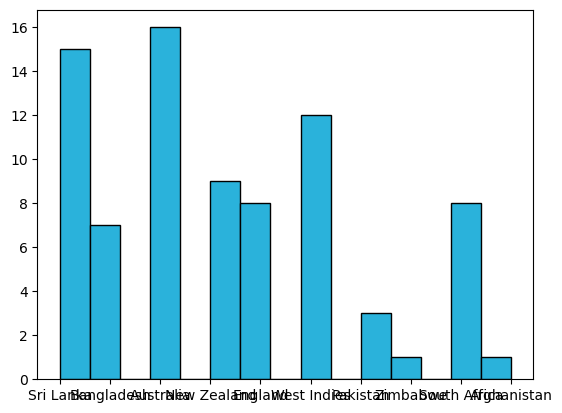

In [56]:
color_palette = ["#2ab2db"]
plt.hist(df["Against"], bins = 15, edgecolor = "black", color = color_palette[0])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sri Lanka'),
  Text(1, 0, 'Bangladesh'),
  Text(2, 0, 'Australia'),
  Text(3, 0, 'New Zealand'),
  Text(4, 0, 'England'),
  Text(5, 0, 'West Indies'),
  Text(6, 0, 'Pakistan'),
  Text(7, 0, 'Zimbabwe'),
  Text(8, 0, 'South Africa'),
  Text(9, 0, 'Afghanistan')])

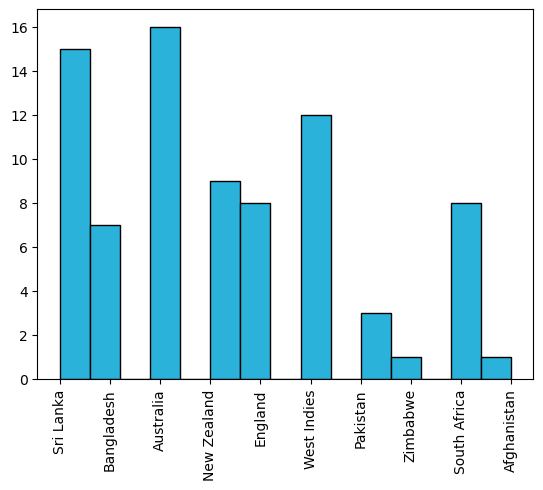

In [57]:
color_palette = ["#2ab2db"]
plt.hist(df["Against"], bins = 15, edgecolor = "black", color = color_palette[0])
plt.xticks(rotation = 90)

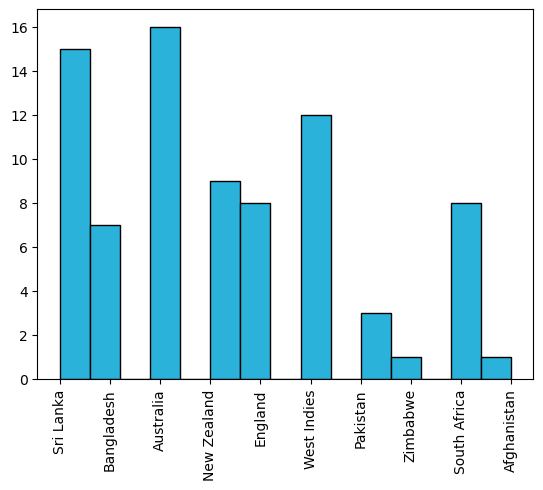

In [58]:
color_palette = ["#2ab2db"]
plt.hist(df["Against"], bins = 15, edgecolor = "black", color = color_palette[0])
plt.xticks(rotation = 90)
plt.show()

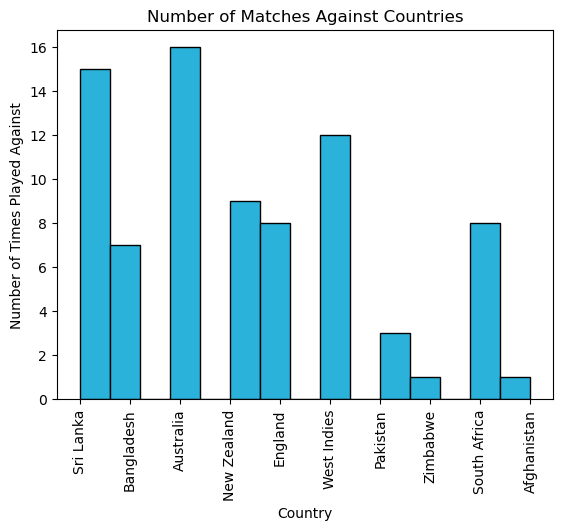

In [59]:
color_palette = ["#2ab2db"]
plt.hist(df["Against"], bins = 15, edgecolor = "black", color = color_palette[0])
plt.xticks(rotation = 90)
plt.xlabel("Country")
plt.ylabel("Number of Times Played Against")
plt.title("Number of Matches Against Countries")
plt.show()

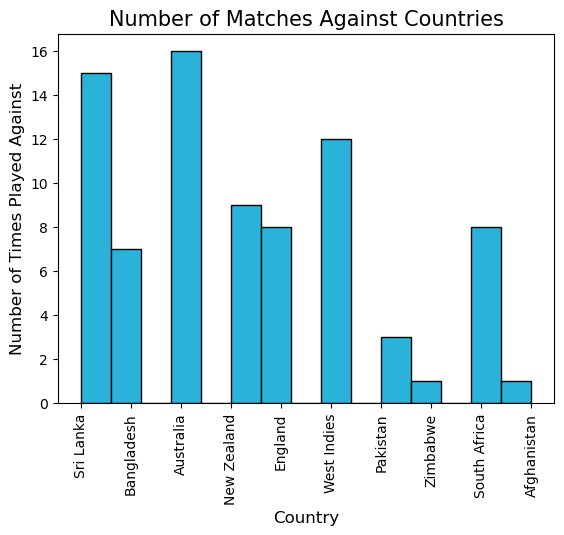

In [60]:
color_palette = ["#2ab2db"]
plt.hist(df["Against"], bins = 15, edgecolor = "black", color = color_palette[0])
plt.xticks(rotation = 90)
plt.xlabel("Country", fontsize = 12)
plt.ylabel("Number of Times Played Against", fontsize = 12)
plt.title("Number of Matches Against Countries", fontsize = 15)
plt.show()

# From the plot above I can understand that he has scored the most centuries against Australia and the least against Zimbabwe and Afghanistan.

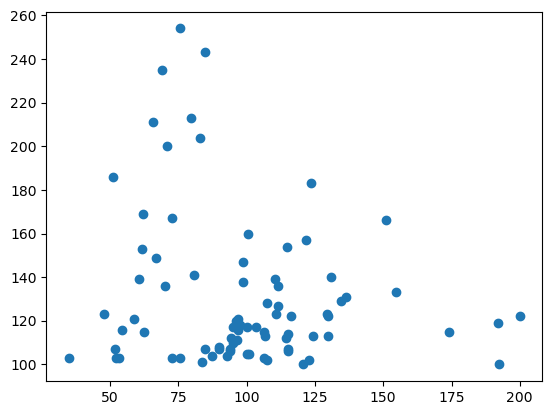

In [62]:
plt.scatter(df["Strike Rate"], df["Score"])

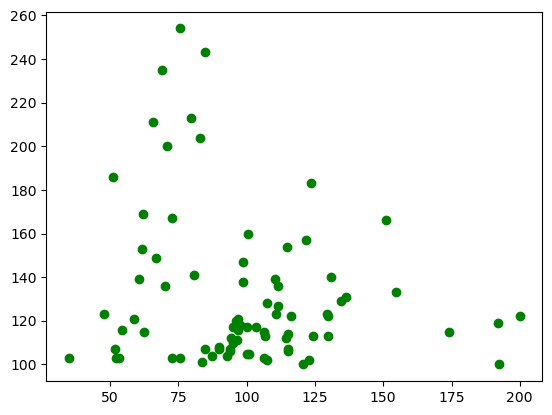

In [63]:
plt.scatter(df["Strike Rate"], df["Score"], color = "green")

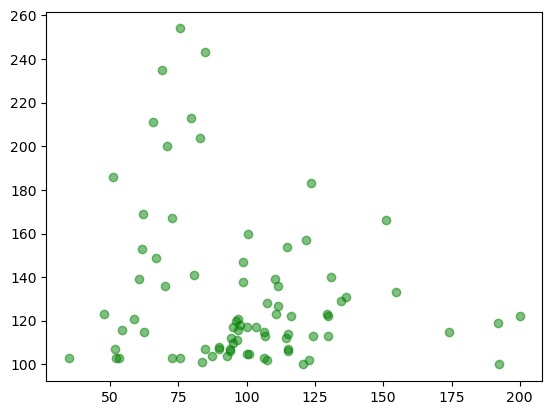

In [64]:
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)

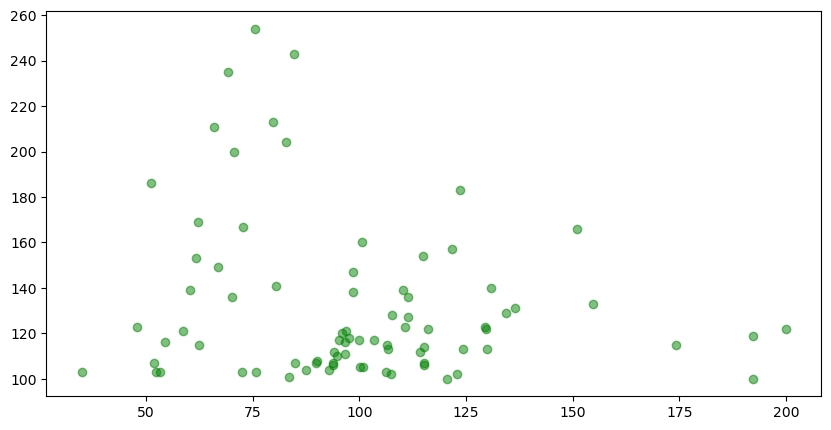

In [65]:
plt.figure(figsize = (10, 5))
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)

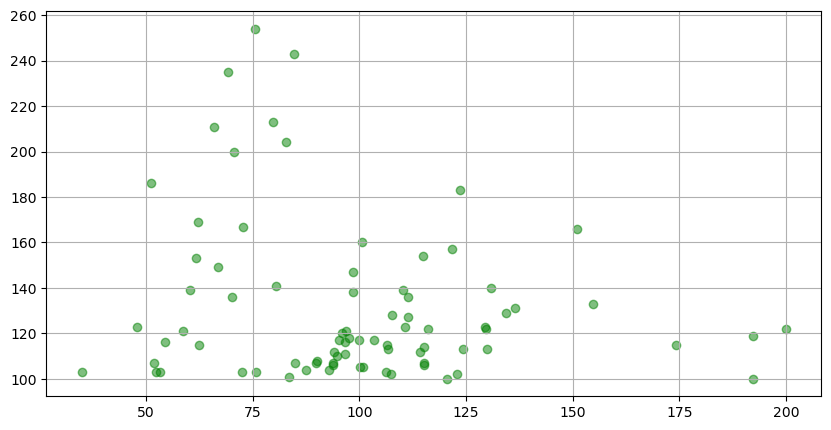

In [66]:
plt.figure(figsize = (10, 5))
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)
plt.grid(True)

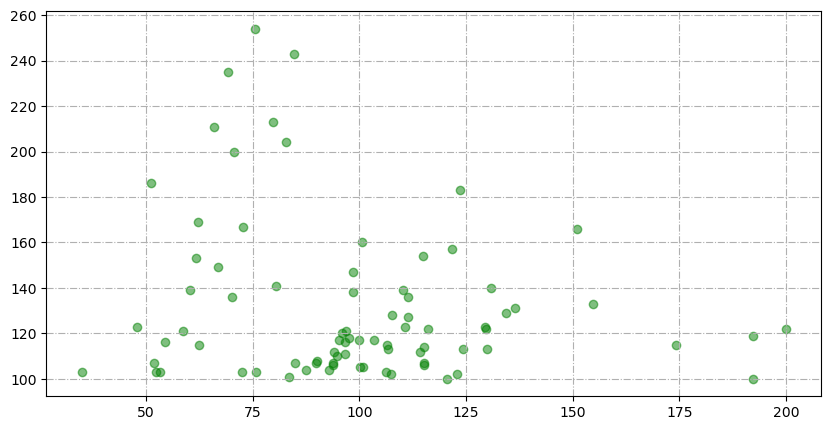

In [67]:
plt.figure(figsize = (10, 5))
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)
plt.grid(True, linestyle = "dashdot")

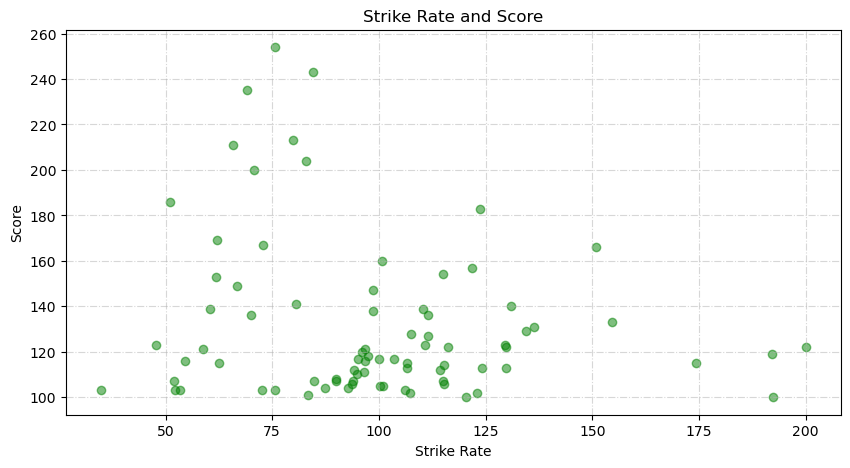

In [68]:
plt.figure(figsize = (10, 5))
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)
plt.xlabel("Strike Rate")
plt.ylabel("Score")
plt.title("Strike Rate and Score")
plt.grid(True, linestyle = "dashdot", alpha = 0.5)

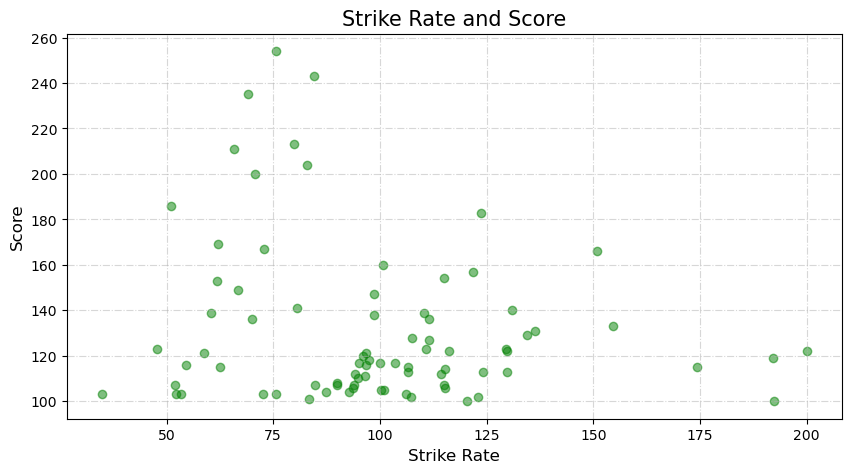

In [69]:
plt.figure(figsize = (10, 5))
plt.scatter(df["Strike Rate"], df["Score"], color = "green", alpha = 0.5)
plt.xlabel("Strike Rate", fontsize = 12)
plt.ylabel("Score", fontsize = 12)
plt.title("Strike Rate and Score", fontsize = 15)
plt.grid(True, linestyle = "dashdot", alpha = 0.5)

# From the plot above I can understand that he scored the most runs in the 50 to 100 range of Strike Rate and I can also infer that his Strike Rate was mostly around the range of 100 and also that the higher the Strike Rate does not mean high score.

([<matplotlib.patches.Wedge at 0x1f5909e8b60>,
 [Text(-0.49738907892327644, 0.9811238984796237, ''),
  Text(0.4569564802357173, -1.000595210447554, ''),
  Text(1.0990845779679979, -0.04486747678339531, '')])

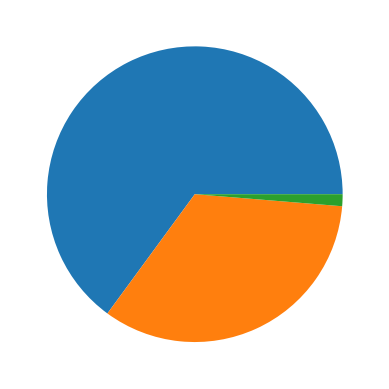

In [71]:
plt.pie([50, 26, 1])

In [72]:
a = df["Type of Match"].value_counts()

In [73]:
a

Type of Match
ODI     50
Test    29
T20      1
Name: count, dtype: int64

In [74]:
a.values

array([50, 29,  1], dtype=int64)

([<matplotlib.patches.Wedge at 0x1f591b6f9e0>,
 [Text(-0.42095177560159874, 1.0162674857624154, ''),
  Text(0.3807288014347596, -1.0320104552561722, ''),
  Text(1.09915194312474, -0.043185714363762236, '')])

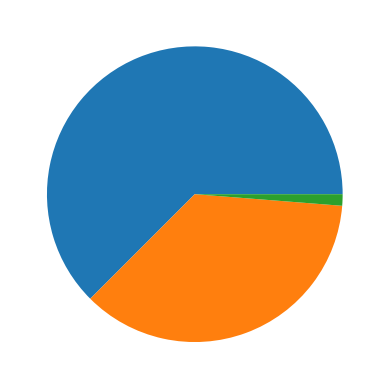

In [75]:
plt.pie(a.values)

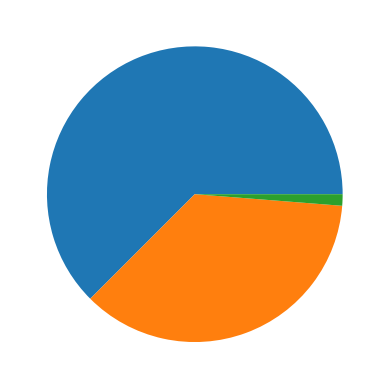

In [76]:
plt.pie(a.values)
plt.show()

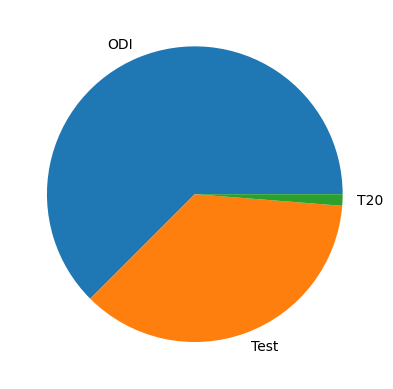

In [77]:
plt.pie(a.values, labels = a.index)
plt.show()

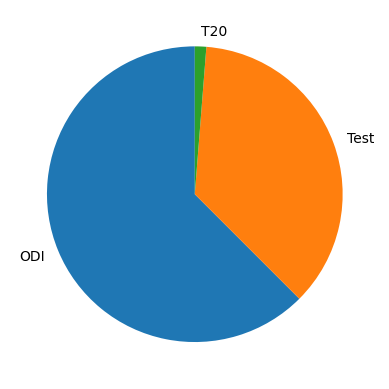

In [78]:
plt.pie(a.values, labels = a.index, startangle = 90)
plt.show()

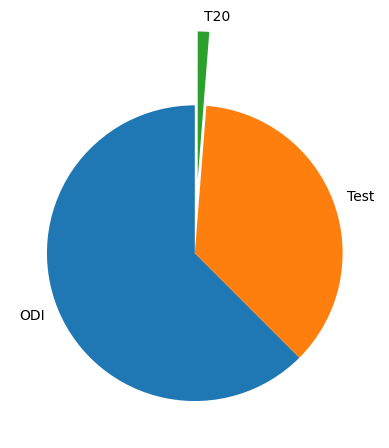

In [79]:
plt.pie(a.values, labels = a.index, startangle = 90, explode = (0, 0, 0.5))
plt.show()

# From the plot above I can infer that he has scored the most number of centuries in the ODI Matches, The second highest in the Test Matches and the least in T20 / T20I Matches.

<BarContainer object of 80 artists>

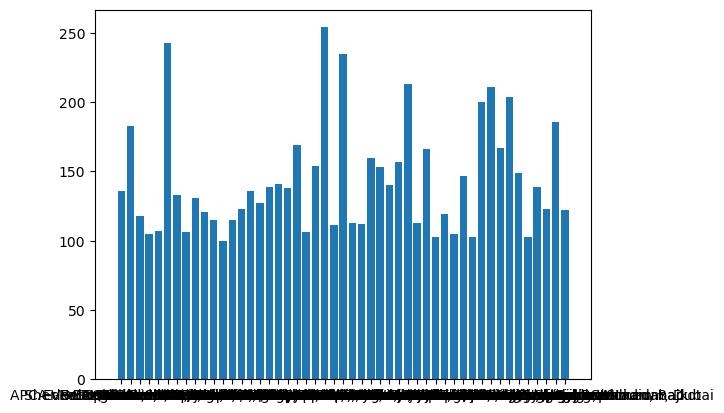

In [81]:
plt.bar(df["Venue"], df["Score"])

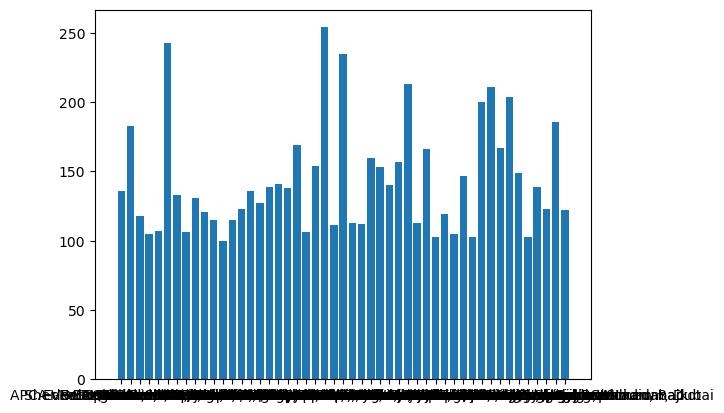

In [82]:
plt.bar(df["Venue"], df["Score"])
plt.show()

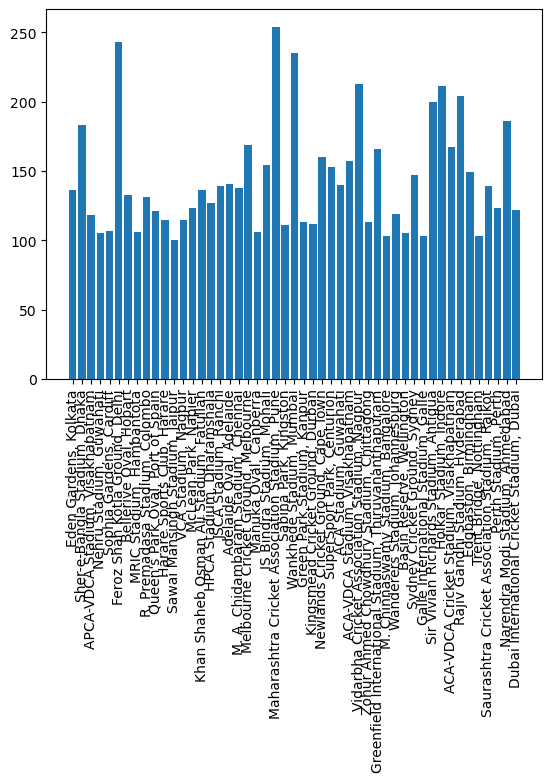

In [83]:
plt.bar(df["Venue"], df["Score"])
plt.xticks(rotation = 90)
plt.show()

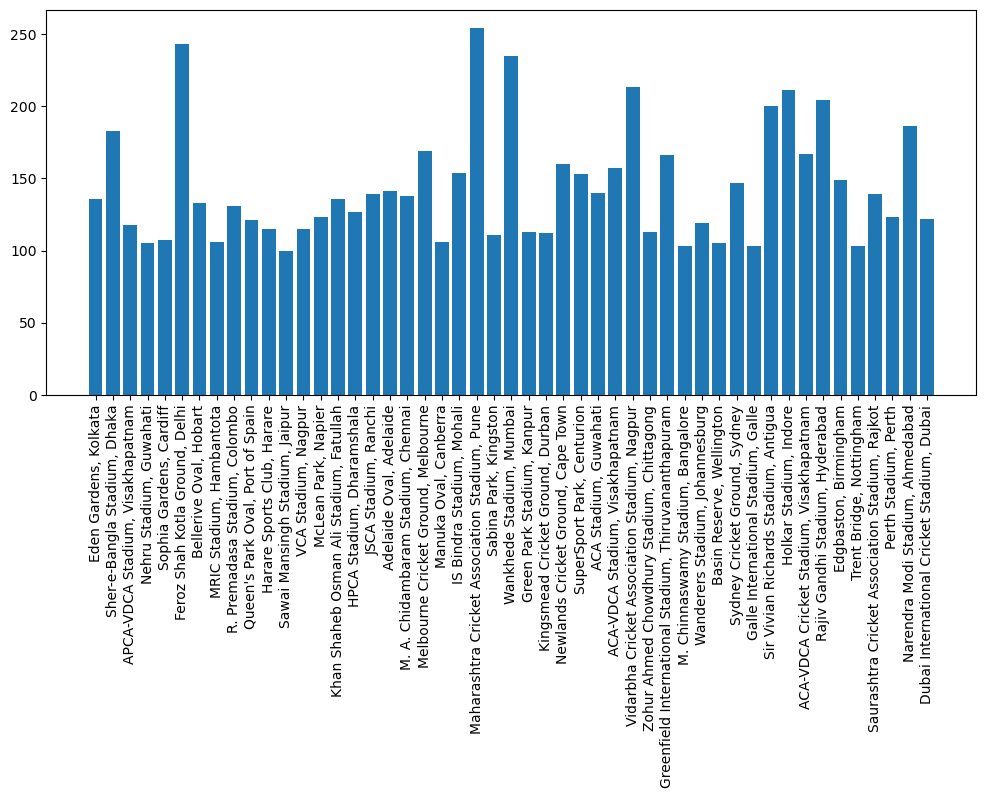

In [84]:
plt.figure(figsize = (12,5))
plt.bar(df["Venue"], df["Score"])
plt.xticks(rotation = 90)
plt.show()

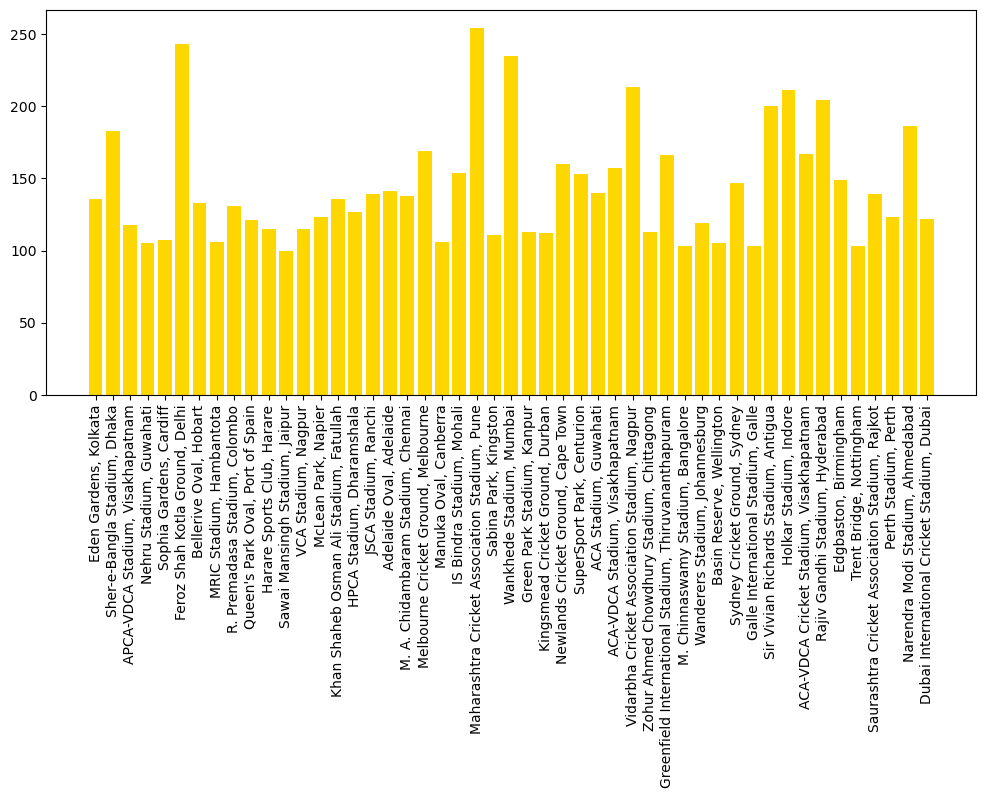

In [85]:
plt.figure(figsize = (12,5))
plt.bar(df["Venue"], df["Score"], color = "gold")
plt.xticks(rotation = 90)
plt.show()

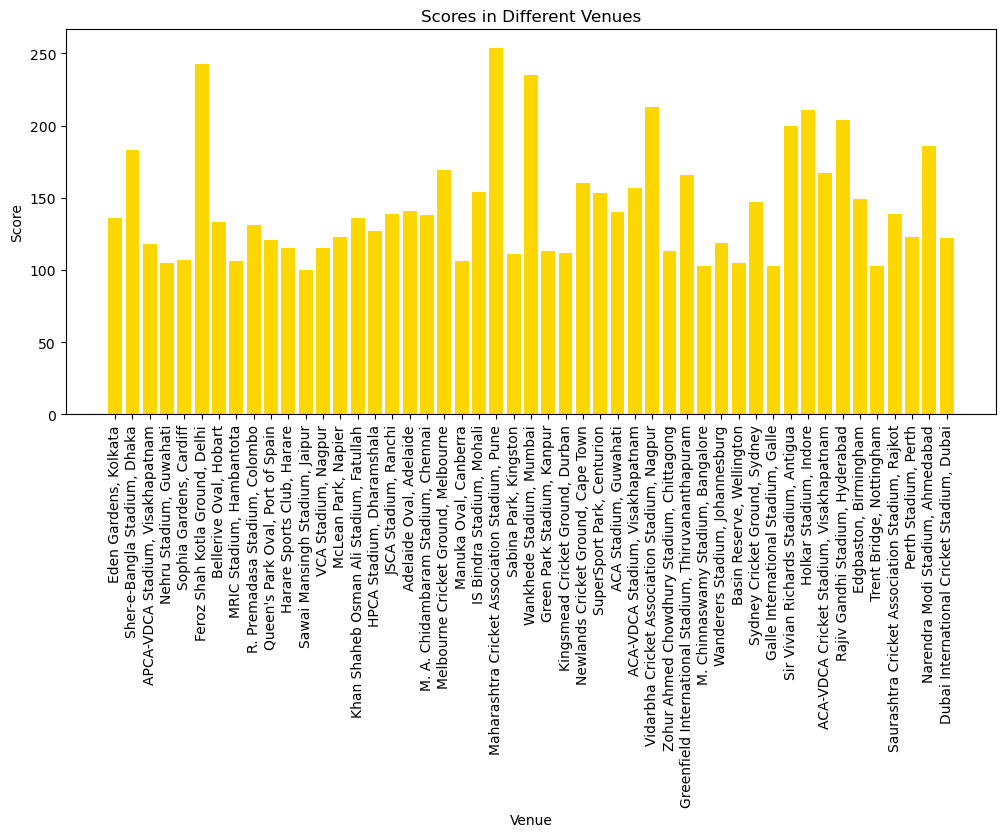

In [86]:
plt.figure(figsize = (12,5))
plt.bar(df["Venue"], df["Score"], color = "gold")
plt.xlabel("Venue")
plt.ylabel("Score")
plt.title("Scores in Different Venues")
plt.xticks(rotation = 90)
plt.show()

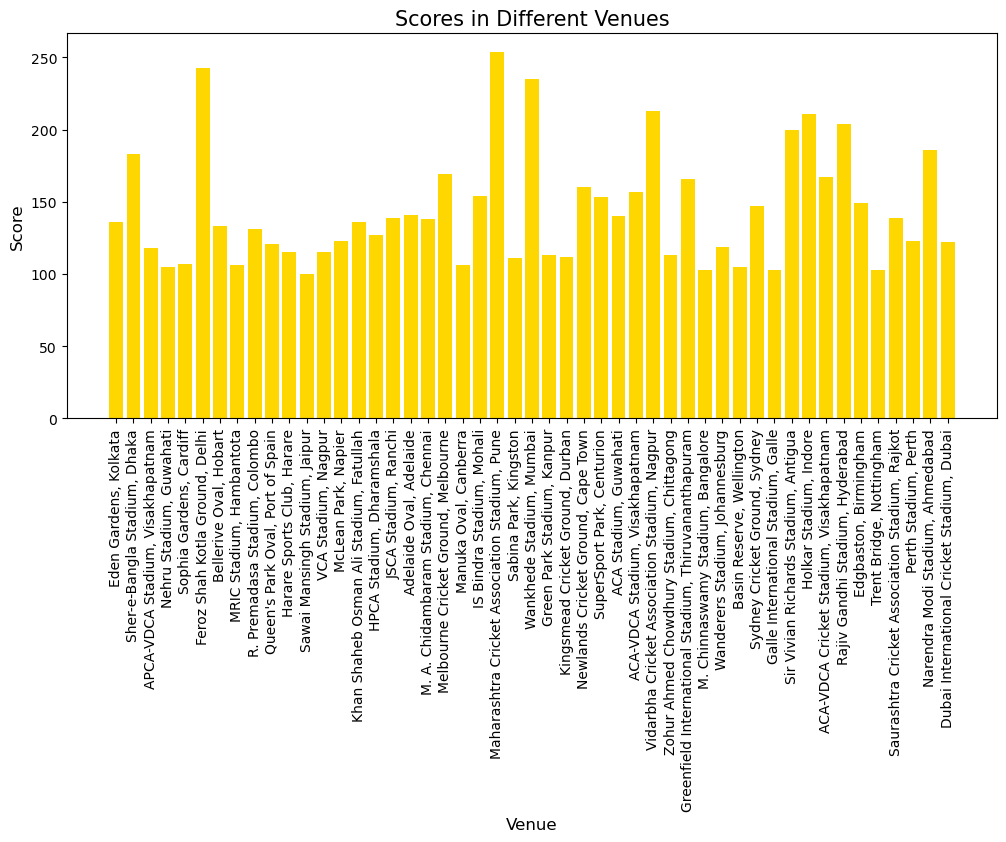

In [87]:
plt.figure(figsize = (12,5))
plt.bar(df["Venue"], df["Score"], color = "gold")
plt.xlabel("Venue", fontsize = 12)
plt.ylabel("Score", fontsize = 12)
plt.title("Scores in Different Venues", fontsize = 15)
plt.xticks(rotation = 90)
plt.show()

# From the plot abouve I can understand that he scored the highest in Indian cities or Home Grounds

# Seaborn

<Axes: xlabel='Result', ylabel='count'>

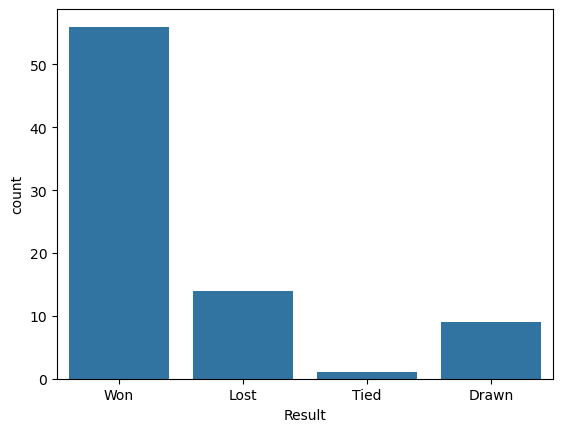

In [90]:
sns.countplot(x='Result', data=df)

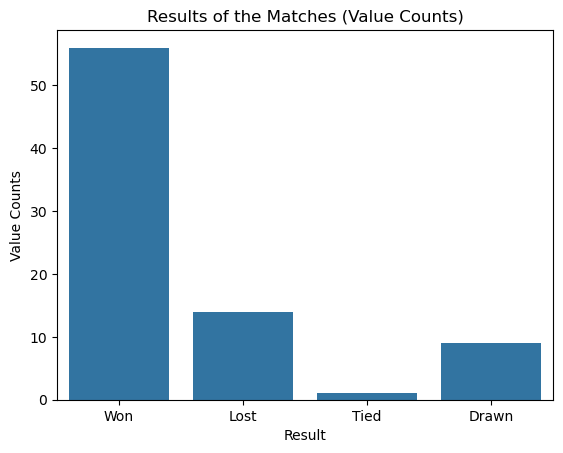

In [91]:
sns.countplot(x='Result', data=df)
plt.ylabel("Value Counts")
plt.title("Results of the Matches (Value Counts)")
plt.show()

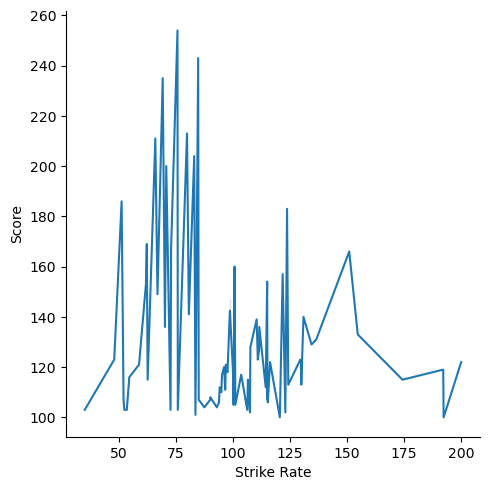

In [92]:
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    kind = "line")

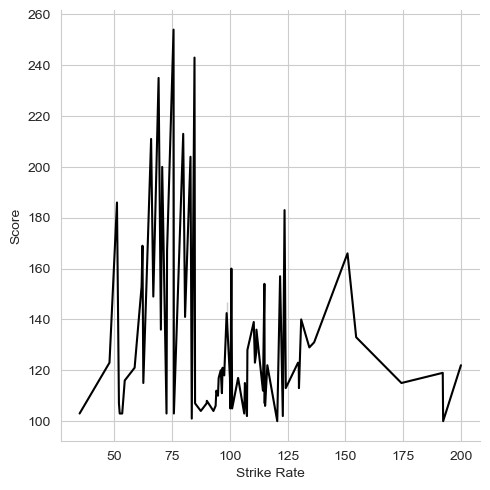

In [93]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    kind = "line")

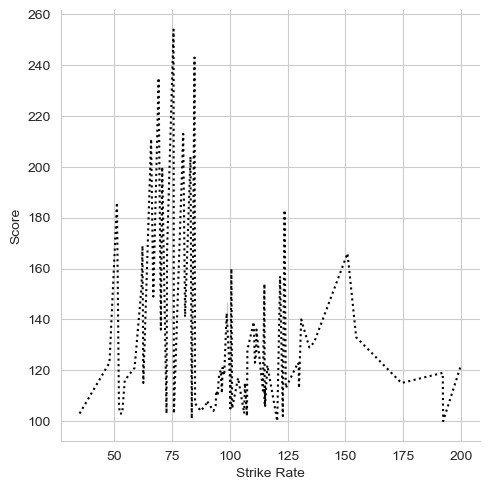

In [94]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    linestyle = "dotted",
    kind = "line")

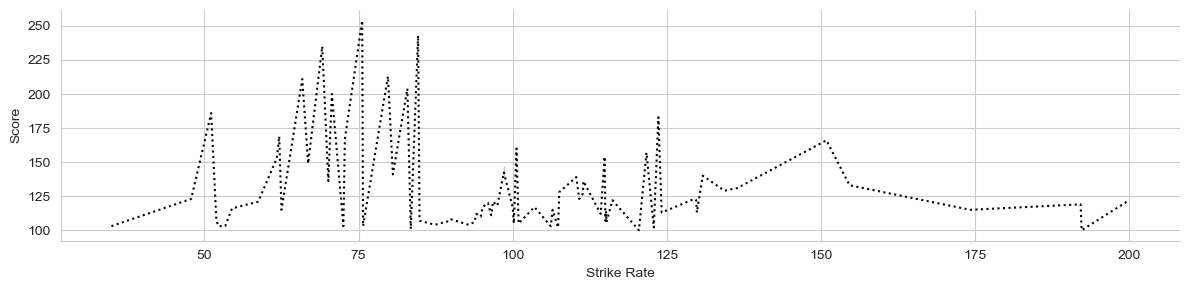

In [95]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    linestyle = "dotted",
    height = 3,
    aspect = 4,
    kind = "line")

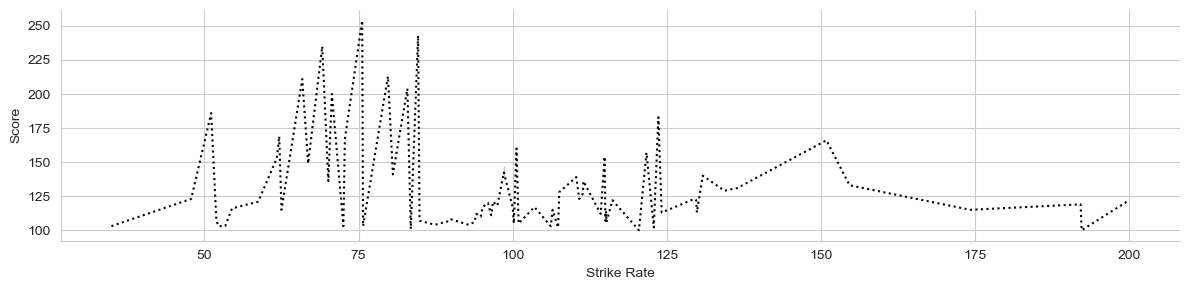

In [96]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    linestyle = "dotted",
    height = 3,
    aspect = 4,
    kind = "line")

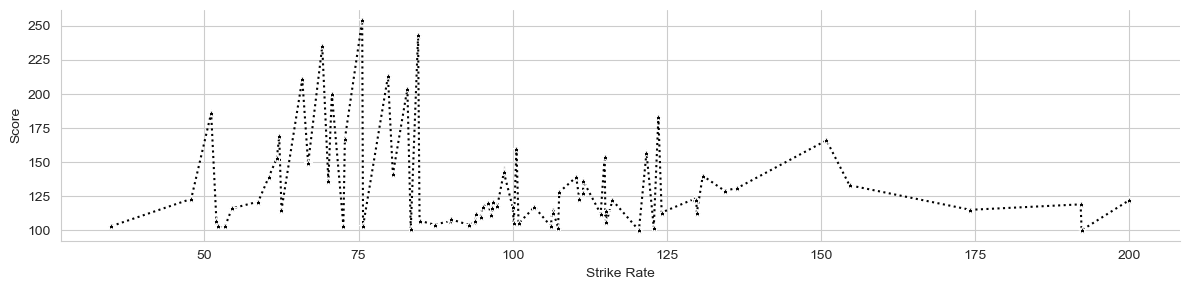

In [97]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    height = 3,
    aspect = 4,
    linestyle = "dotted",
    marker = "*",
    kind = "line")

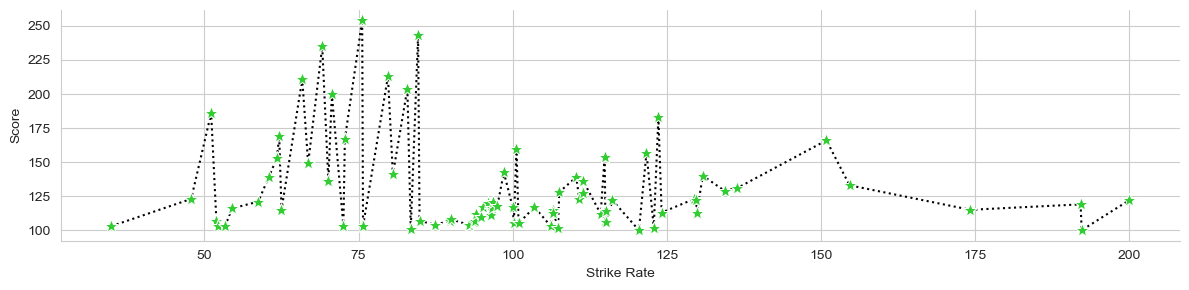

In [98]:
sns.set_style("whitegrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    color = "black",
    height = 3,
    aspect = 4,
    linestyle = "dotted",
    marker = "*",
    markerfacecolor = "limegreen",
    markersize = 10,
    kind = "line")

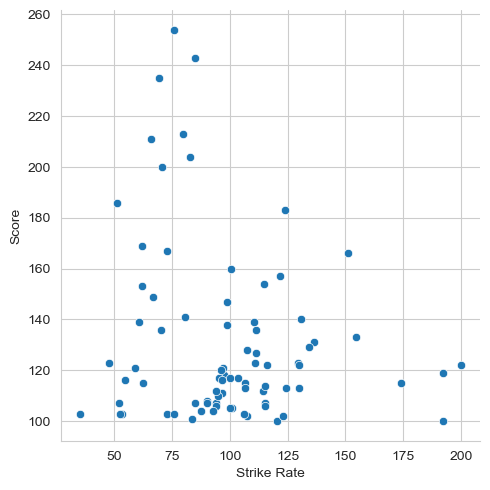

In [99]:
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    kind = "scatter")

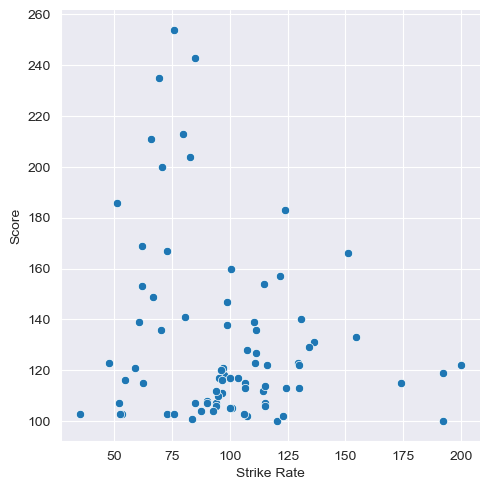

In [100]:
sns.set_style("darkgrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    kind = "scatter")

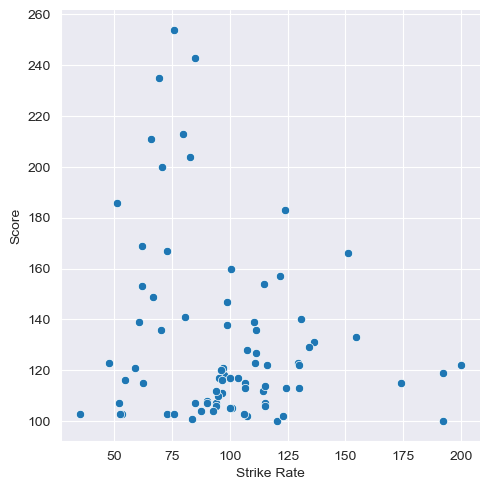

In [101]:
sns.set_style("darkgrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    kind = "scatter")

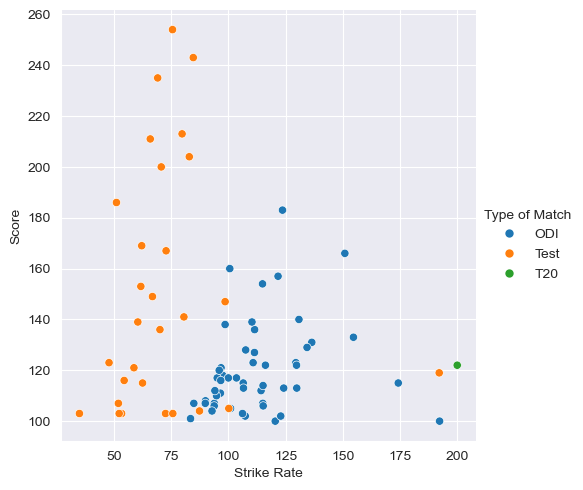

In [102]:
sns.set_style("darkgrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    hue = "Type of Match",
    kind = "scatter")

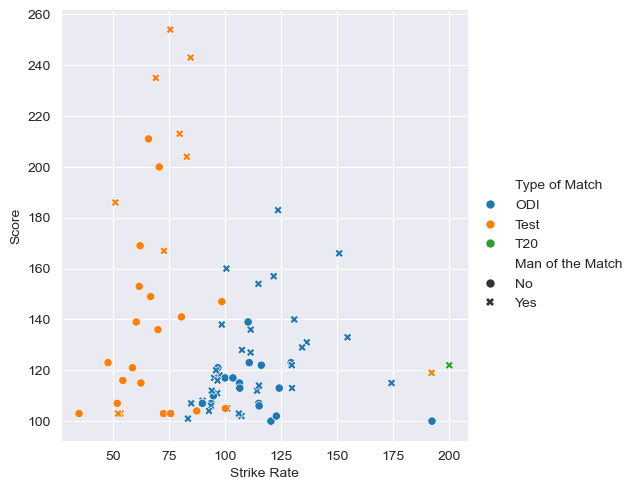

In [103]:
sns.set_style("darkgrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    hue = "Type of Match",
    style = "Man of the Match",
    kind = "scatter")

In [104]:
#  Double click to expand

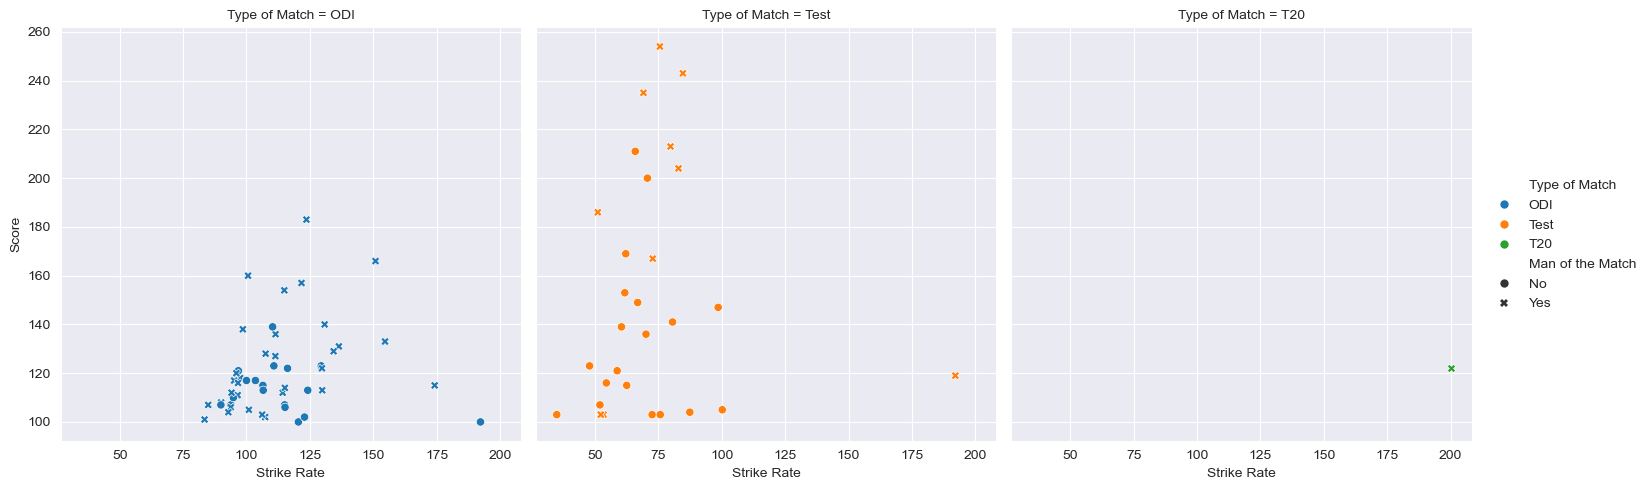

In [105]:
sns.set_style("darkgrid")
sns.relplot(
    data = df,
    x = "Strike Rate",
    y = "Score",
    hue = "Type of Match",
    style = "Man of the Match",
    col = "Type of Match",
    kind = "scatter")

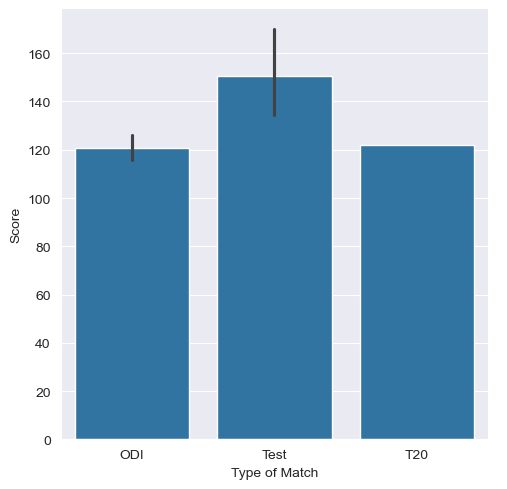

In [106]:
sns.catplot(
    data = df,
    x = "Type of Match",
    y = "Score",
    kind = "bar")

<Axes: xlabel='Position', ylabel='Score'>

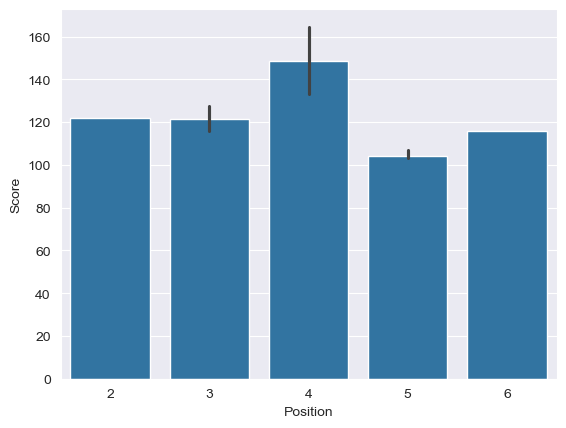

In [107]:
sns.barplot(x='Position', y='Score', data=df)

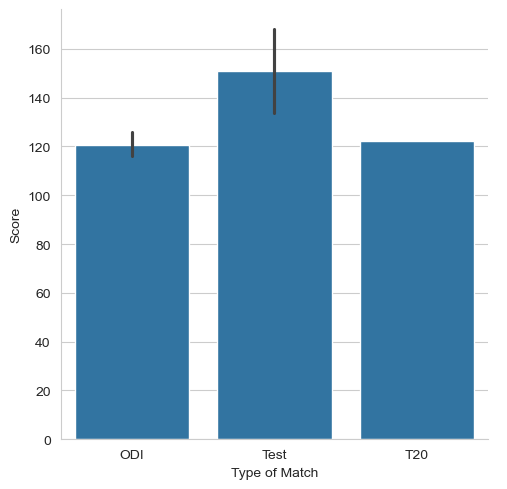

In [108]:
sns.set_style('whitegrid')
sns.catplot(
    data = df,
    x = "Type of Match",
    y = "Score",
    kind = "bar")

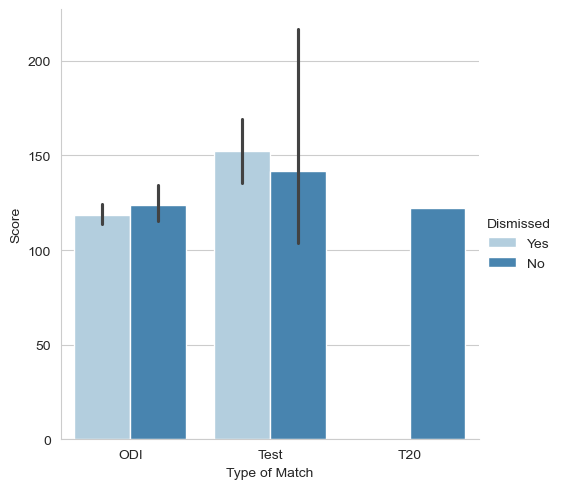

In [109]:
sns.set_style('whitegrid')
sns.catplot(
    data = df,
    x = "Type of Match",
    y = "Score",
    hue = "Dismissed",
    palette = "Blues",
    kind = "bar")

<Axes: xlabel='Score'>

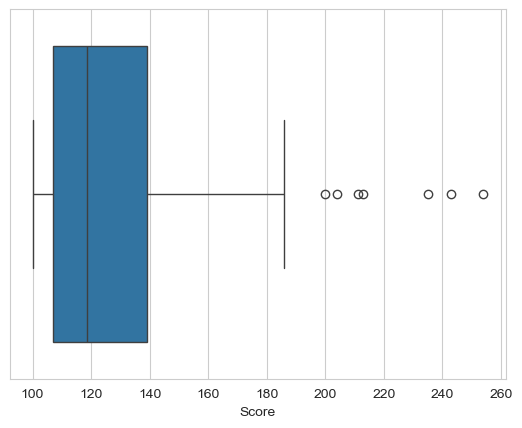

In [110]:
sns.boxplot(data = df, x = "Score")

<Axes: xlabel='Score', ylabel='Type of Match'>

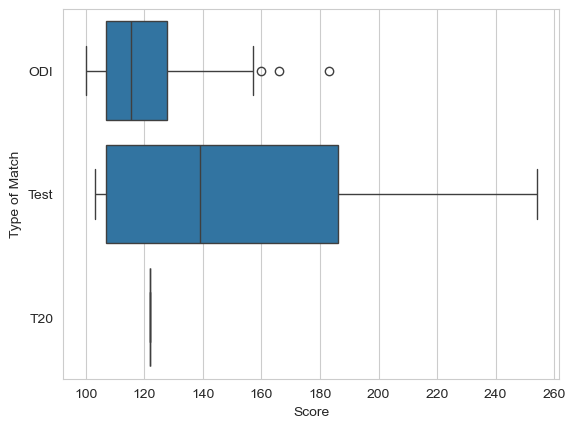

In [111]:
sns.boxplot(data = df, x = "Score", y = "Type of Match")

<Axes: xlabel='Type of Match', ylabel='Score'>

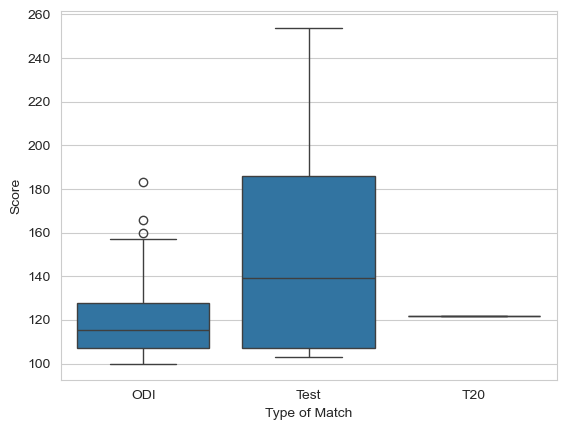

In [112]:
sns.boxplot(data = df, x = "Type of Match", y = "Score")

<Axes: xlabel='Type of Match', ylabel='Score'>

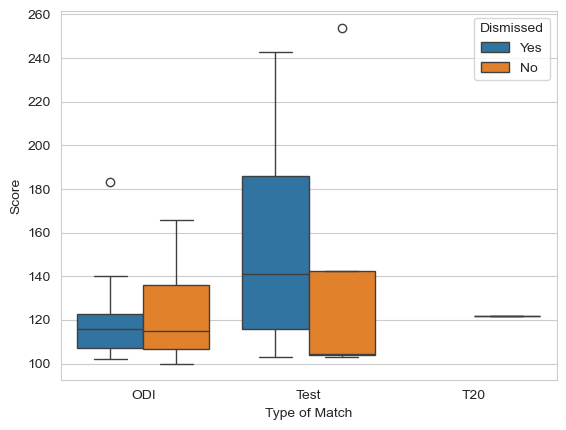

In [113]:
sns.boxplot(data = df, x = "Type of Match", y = "Score", hue = "Dismissed")

<Axes: xlabel='Type of Match', ylabel='Score'>

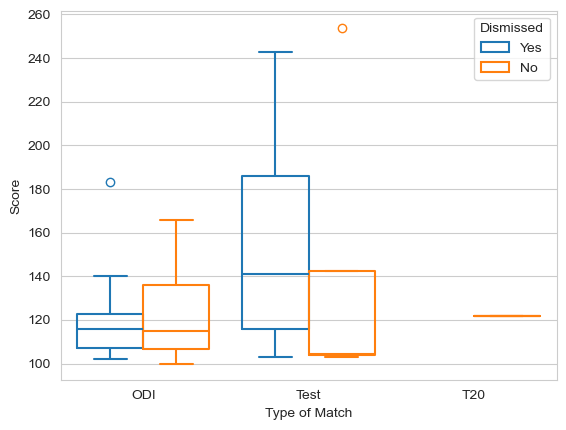

In [114]:
sns.boxplot(data = df, x = "Type of Match", y = "Score", hue = "Dismissed", fill = False)

<Axes: ylabel='Score'>

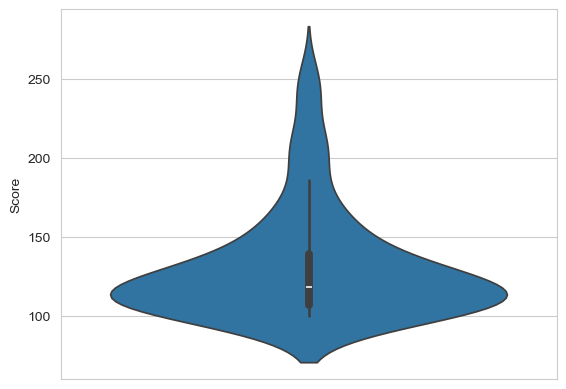

In [115]:
sns.violinplot(data = df, y = "Score")

<Axes: xlabel='H/A/N', ylabel='Score'>

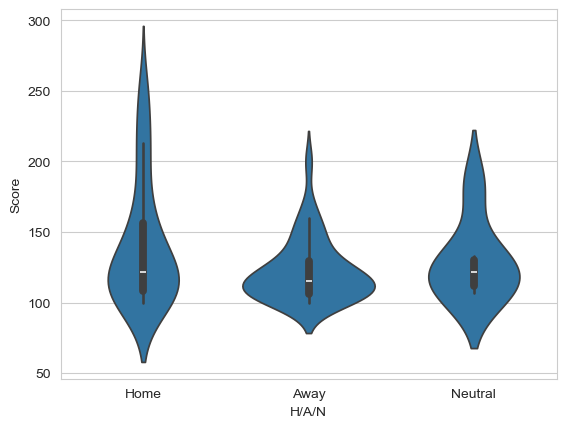

In [116]:
sns.violinplot(data = df, y = "Score", x = "H/A/N")

<Axes: xlabel='H/A/N', ylabel='Score'>

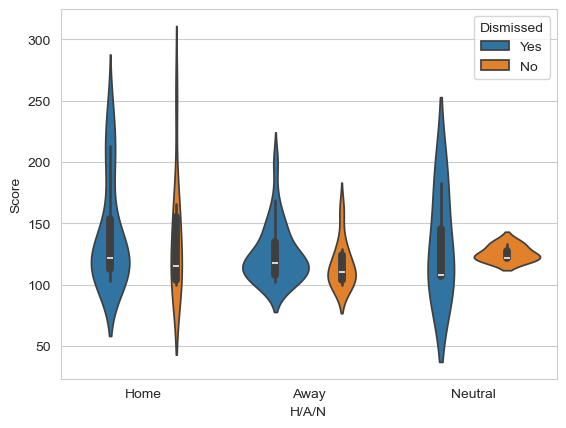

In [117]:
sns.violinplot(data = df, y = "Score", x = "H/A/N", hue = "Dismissed")

# Word Cloud

In [119]:
t_data = df["Against"]
t_data_str = t_data.to_string()

In [120]:
wc1 = WordCloud(width = 800, height = 400, background_color = "black").generate(t_data_str)

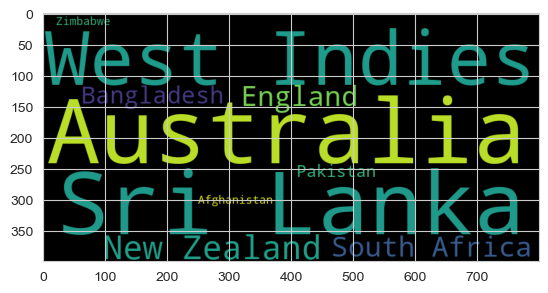

In [121]:
plt.imshow(wc1)

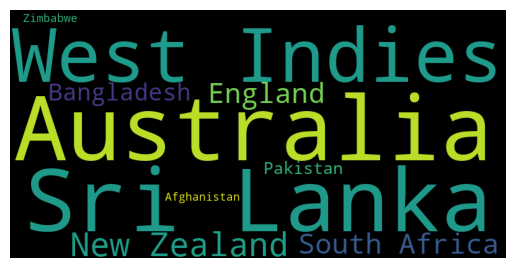

In [122]:
plt.imshow(wc1)
plt.axis("off")
plt.show()

In [135]:
t_data2 = df["Against"].value_counts()
t_data_dict = t_data2.to_dict()

In [137]:
wc2 = WordCloud(width = 800, height = 400, background_color = "black").generate_from_frequencies(t_data_dict)

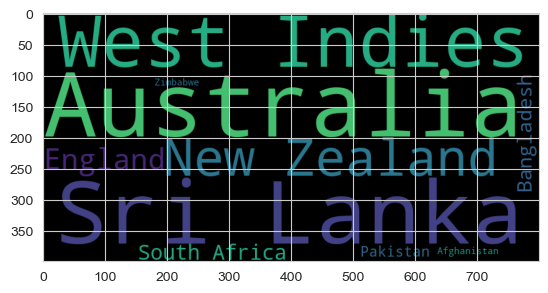

In [139]:
plt.imshow(wc2)

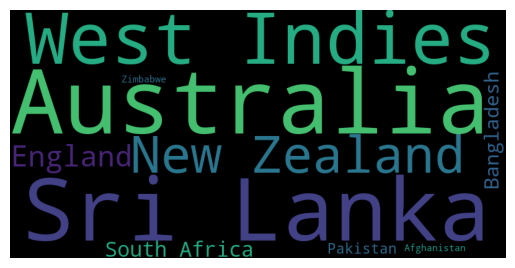

In [141]:
plt.imshow(wc2)
plt.axis("off")
plt.show()

# -------------------------------------T H E - E N D-------------------------------------